# Memory Capacity Hyperparameter Tuning & Visualization

This notebook evaluates the Memory Capacity (MC) of a connectome (reservoir) and helps visualize the effect of important hyperparameters like **spectral radius** and **input scaling**.

We will:
1. Load or generate a sample connectome.
2. Formulate the ESN (Echo State Network) equations manually to visualize what happens inside the reservoir.
3. Show the activation of the neurons to check if they are saturating (input weights too strong) or too quiet (input weights too weak).
4. Show the effect of the spectral radius on the memory trace (spectral radius must be < 1 for the Echo State Property, but close to 1 for long memory).
5. Evaluate Linear and Non-linear Memory Capacity correctly (predicting past inputs, NOT future inputs).
\n

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from scipy import linalg
import seaborn as sns
from sklearn.linear_model import Ridge

plt.rcParams['figure.figsize'] = (10, 6)
sns.set_context("notebook", font_scale=1.2)


## 1. Create a Sample Connectome
We'll generate a random directed graph to serve as our connectome reservoir.\n

In [11]:
# # Generate a random Erdos-Renyi directed graph (or load your own connectome here)
# N = 100 # number of neurons
# p = 0.1 # sparsity
# A = np.random.rand(N, N) < p
# A = A.astype(float)
# np.fill_diagonal(A, 0)

A = np.load("/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/data/preprocessed/lexis_data_developing/01_connectomes/00_individual_connectomes_bin.npy") 
A = A.astype(float)[0]
print(A.shape)
# Randomize weights (Dale's law approximation: some excitatory, some inhibitory)
signs = np.random.choice([-1, 1], size=N, p=[0.2, 0.8])
W_raw = A * signs[:, np.newaxis]

print(f"Connectome setup: {N} neurons, {np.sum(A)} edges.")


(100, 100)
Connectome setup: 100 neurons, 990.0 edges.


## 2. Setting up the Reservoir Dynamics
The core update rule of an ESN is:
$x(t+1) = (1 - \alpha) x(t) + \alpha \tanh(W x(t) + W_{in} u(t) + b)$

Where:
- $W$ is the reservoir matrix (scaled to `spectral_radius`)
- $W_{in}$ is the input weight matrix (scaled by `input_scaling`)
- $u(t)$ is the input at time $t$
- $\alpha$ is the leak rate (1.0 = no leak)
- $b$ is the bias
\n

In [12]:
def prepare_reservoir(W_raw, spectral_radius):
    eigenvalues = linalg.eigvals(W_raw)
    rho = np.max(np.abs(eigenvalues))
    if rho > 0:
        W = W_raw * (spectral_radius / rho)
    else:
        W = W_raw
    return W

def run_reservoir(W, inputs, input_scaling, leak_rate=1.0, bias_scale=0.1, seed=42):
    rng = np.random.RandomState(seed)
    N = W.shape[0]
    T = len(inputs)
    
    # Input weights: uniform [-1, 1] scaled by input_scaling
    W_in = rng.uniform(-1, 1, size=(N, 1)) * input_scaling
    bias = rng.uniform(-bias_scale, bias_scale, size=N)
    
    states = np.zeros((T, N))
    x = np.zeros(N)
    
    for t in range(T):
        u = inputs[t]
        x_new = np.tanh(W @ x + W_in[:, 0] * u + bias)
        x = (1 - leak_rate) * x + leak_rate * x_new
        states[t] = x
        
    return states, W_in


## 3. Visualizing the Effect of Input Scaling
Input scaling determines how hard the external input drives the network.
- If **too weak**: The signal is lost in the internal dynamics; neurons barely react to the input.
- If **too strong**: The `tanh` function saturates (activations hit -1 or 1 and stay there). Linear memory is destroyed because the non-linearity wipes out the signal history.
\n

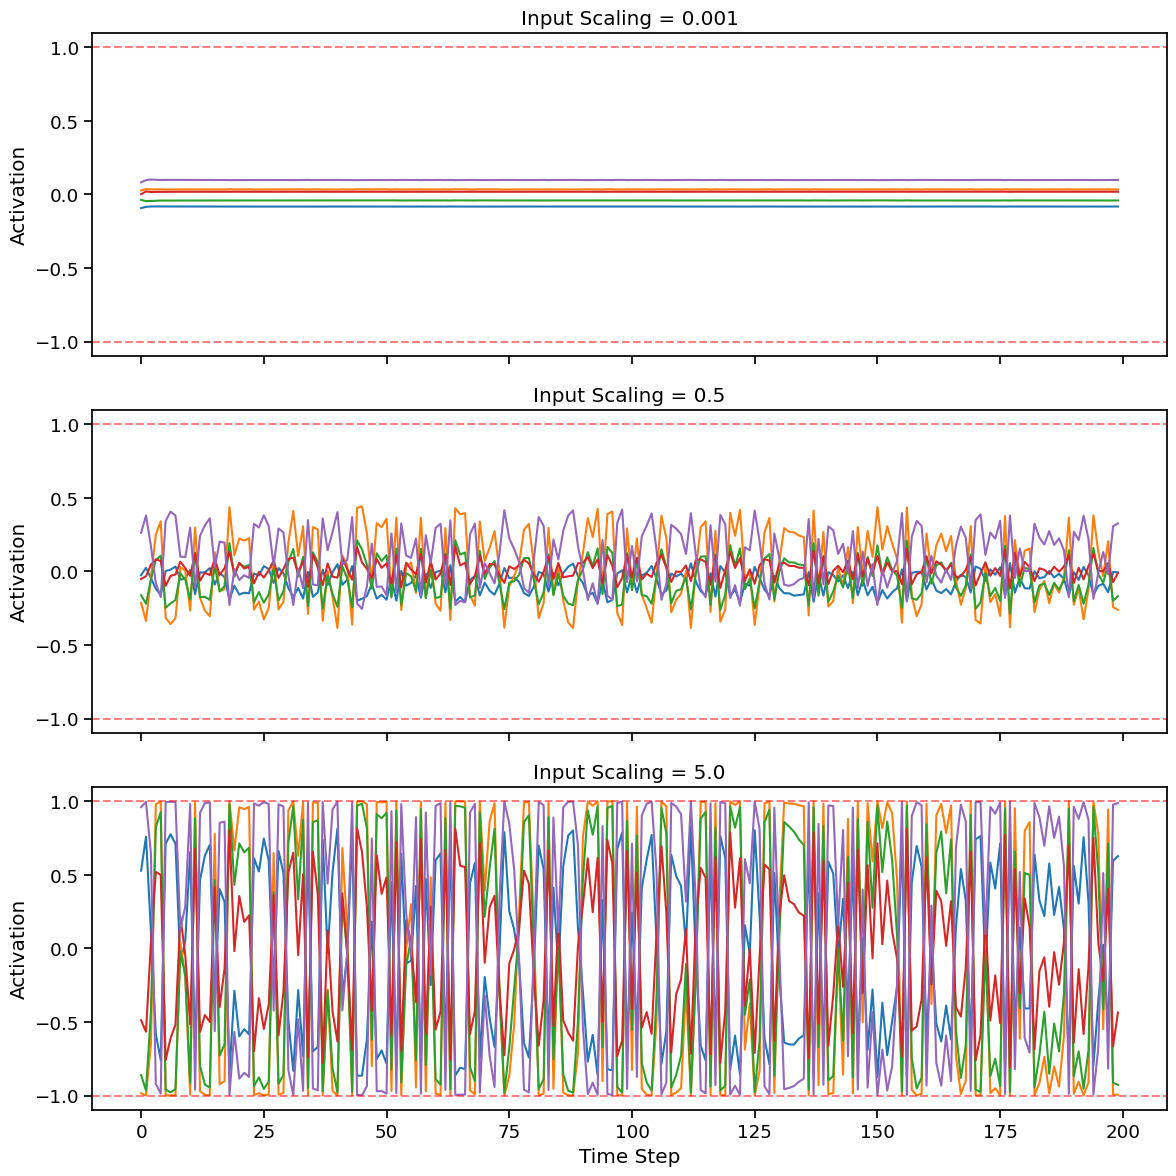

In [13]:
T_viz = 200
inputs_viz = np.random.uniform(-1, 1, T_viz)

W_base = prepare_reservoir(W_raw, spectral_radius=0.95)

fig, axes = plt.subplots(3, 1, figsize=(12, 12), sharex=True)

for ax, inp_scale in zip(axes, [0.001, 0.5, 5.0]):
    states, _ = run_reservoir(W_base, inputs_viz, input_scaling=inp_scale)
    
    # Plot activity of 5 random neurons
    for i in range(5):
        ax.plot(states[:, i], label=f"Neuron {i}" if i==0 else "")
    
    ax.set_title(f"Input Scaling = {inp_scale}")
    ax.set_ylim(-1.1, 1.1)
    ax.axhline(1, color='red', linestyle='--', alpha=0.5)
    ax.axhline(-1, color='red', linestyle='--', alpha=0.5)
    ax.set_ylabel("Activation")

axes[-1].set_xlabel("Time Step")
plt.tight_layout()
plt.show()


## 4. Visualizing the Effect of Spectral Radius
The spectral radius controls how long the internal dynamics of the network persist.
For the Echo State Property to hold smoothly, it is typically set < 1 (e.g., 0.9 to 0.99).
- If **too low**: The network forgets instantly.
- If **> 1**: The network might become chaotic and spontaneous noise overpowers the input.
\n

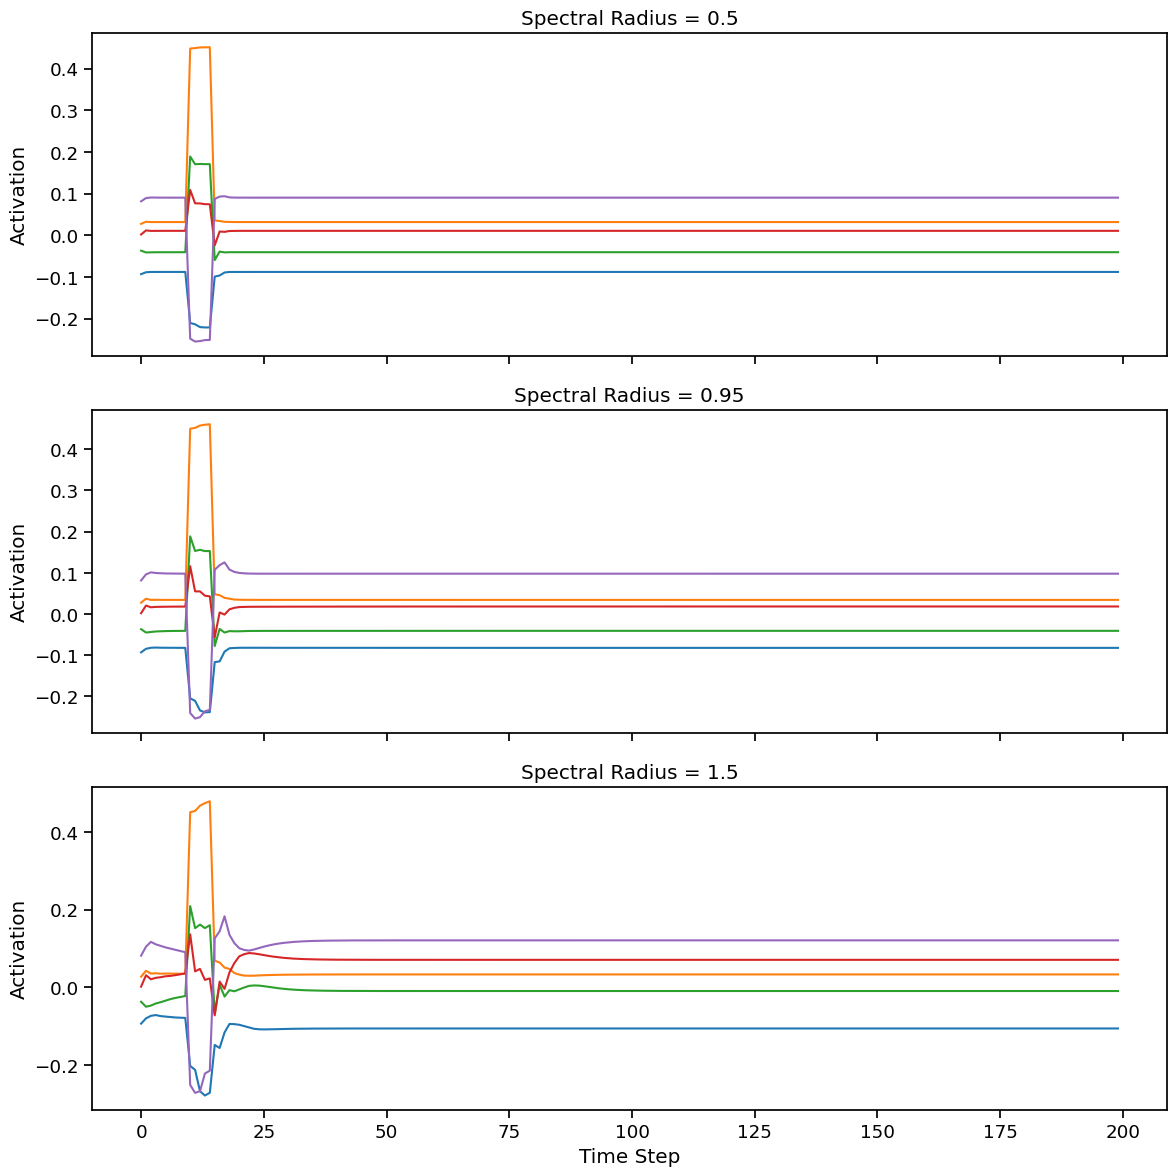

In [15]:
fig, axes = plt.subplots(3, 1, figsize=(12, 12), sharex=True)

# Generate an impulse to see how it fades
inputs_impulse = np.zeros(200)
inputs_impulse[10:15] = 1.0  # short impulse

for ax, rho in zip(axes, [0.5, 0.95, 1.5]):
    W_rho = prepare_reservoir(W_raw, spectral_radius=rho)
    states, _ = run_reservoir(W_rho, inputs_impulse, input_scaling=0.5)
    
    for i in range(5):
        ax.plot(states[:, i], label=f"Neuron {i}" if i==0 else "")
    
    ax.set_title(f"Spectral Radius = {rho}")
    ax.set_ylabel("Activation")

axes[-1].set_xlabel("Time Step")
plt.tight_layout()
plt.show()


## 5. Properly Evaluating Memory Capacity
The correct way to formulate MC is to ask the network to reconstruct *past* inputs. 
Target for lag $k$: $y_{target}(t) = u(t-k)$

If you try to predict $u(t+k)$ on a random noise sequence, you are asking the network to forecast the unpredictable future, which results in $R^2 \approx 0$.
\n

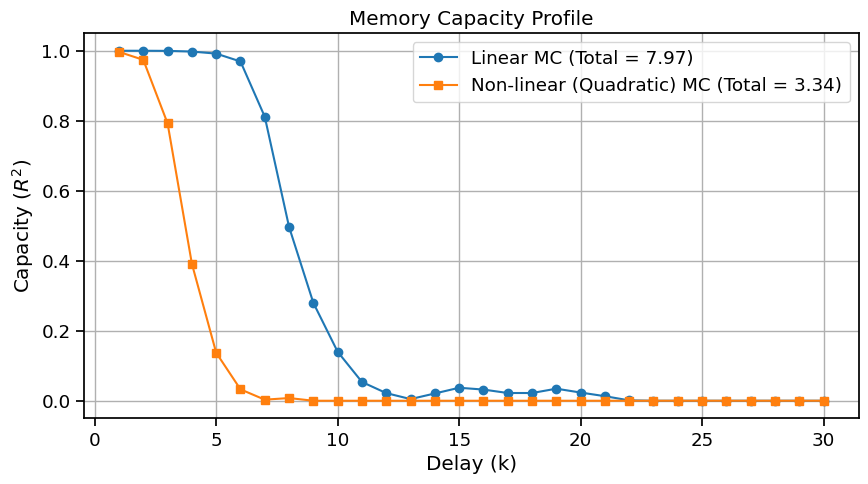

In [16]:
def evaluate_memory_capacities(W_raw, spectral_radius=0.95, input_scaling=0.5, max_delay=30):
    # Setup
    T_train = 2000
    T_test = 500
    T_washout = 200
    T_total = T_train + T_test + T_washout + max_delay
    
    inputs = np.random.uniform(-1, 1, T_total)
    W = prepare_reservoir(W_raw, spectral_radius)
    states, _ = run_reservoir(W, inputs, input_scaling)
    
    states = states[T_washout:]
    inputs = inputs[T_washout:]
    
    # States available for training/testing (we start from max_delay so we have history)
    S_valid = states[max_delay:]
    S_train = S_valid[:T_train]
    S_test = S_valid[T_train : T_train + T_test]
    
    # Evaluate Linear MC
    linear_mc = []
    nonlinear_mc = []
    
    for k in range(1, max_delay + 1):
        # The target is the input k steps in the past
        target_seq = inputs[max_delay - k : max_delay - k + T_train + T_test]
        
        # 1. Linear target
        y_train = target_seq[:T_train]
        y_test = target_seq[T_train : T_train + T_test]
        
        model_lin = Ridge(alpha=1e-4)
        model_lin.fit(S_train, y_train)
        score_lin = model_lin.score(S_test, y_test)
        linear_mc.append(max(0, score_lin)) # R^2
        
        # 2. Non-linear target (quadratic)
        y_train_nl = y_train**2
        y_test_nl = y_test**2
        
        model_nl = Ridge(alpha=1e-4)
        model_nl.fit(S_train, y_train_nl)
        score_nl = model_nl.score(S_test, y_test_nl)
        nonlinear_mc.append(max(0, score_nl))
        
    return linear_mc, nonlinear_mc

lin_mc, nonlin_mc = evaluate_memory_capacities(W_raw, spectral_radius=0.99, input_scaling=0.5)

plt.figure(figsize=(10, 5))
plt.plot(range(1, len(lin_mc)+1), lin_mc, marker='o', label=f'Linear MC (Total = {sum(lin_mc):.2f})')
plt.plot(range(1, len(nonlin_mc)+1), nonlin_mc, marker='s', label=f'Non-linear (Quadratic) MC (Total = {sum(nonlin_mc):.2f})')
plt.xlabel("Delay (k)")
plt.ylabel("Capacity ($R^2$)")
plt.title("Memory Capacity Profile")
plt.legend()
plt.grid(True)
plt.show()
